**DSA506 - Visual Analytics and Communications**  
**Final Test - Problem 2**  
**Michelle Richardson**  

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import plotly.express as px
from IPython.display import HTML



I chose the SP&P 500 Index, crude oil and bitcoin for my plots.  

In [2]:
plot_path = 'Problem2Plots'   # HTML plots stored here

In [3]:
# Source Yahoo Finance
sp500 = yf.download("^GSPC", period="1y")
crude = yf.download("CL=F", period="1y")
ethereum = yf.download("ETH-USD", period="1y")    

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


# S&P 500 Index

In [4]:
sp500.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2025-07-22,6309.620117,6316.120117,6281.709961,6306.600098,5662040000
2025-07-23,6358.910156,6360.640137,6317.490234,6326.899902,5642510000
2025-07-24,6363.350098,6381.310059,6360.569824,6368.600098,5282720000
2025-07-25,6388.640137,6395.819824,6368.529785,6370.009766,4470720000
2025-07-28,6389.770020,6401.069824,6375.790039,6397.689941,4565620000


In [5]:
sp500.describe()


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,6890.221833,6920.923173,6854.217882,6889.262625,5.377688e+09
std,354.532266,354.671637,352.304838,352.545094,9.275907e+08
min,6238.009766,6287.279785,6212.689941,6271.709961,1.798270e+09
25%,6635.080078,6678.094971,6604.094971,6638.864990,4.960245e+09
50%,6840.509766,6871.169922,6808.459961,6837.370117,5.328060e+09
75%,7108.770020,7137.955078,7062.375000,7109.979980,5.731650e+09
max,7609.779785,7620.899902,7582.990234,7605.310059,1.002582e+10


<Axes: title={'center': 'S&P100 - 1 year'}, xlabel='Date'>

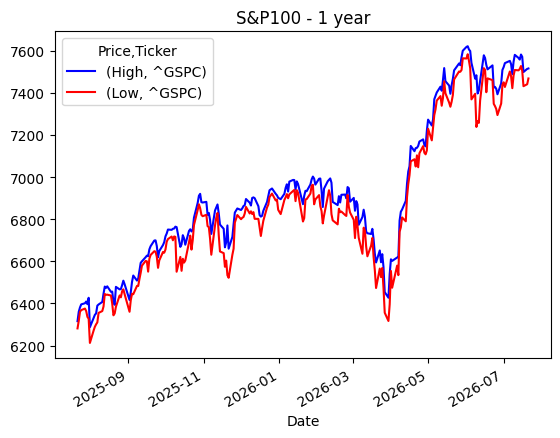

In [6]:
sp500.plot(y=['High','Low'], title='S&P100 - 1 year', color=['blue','red'])


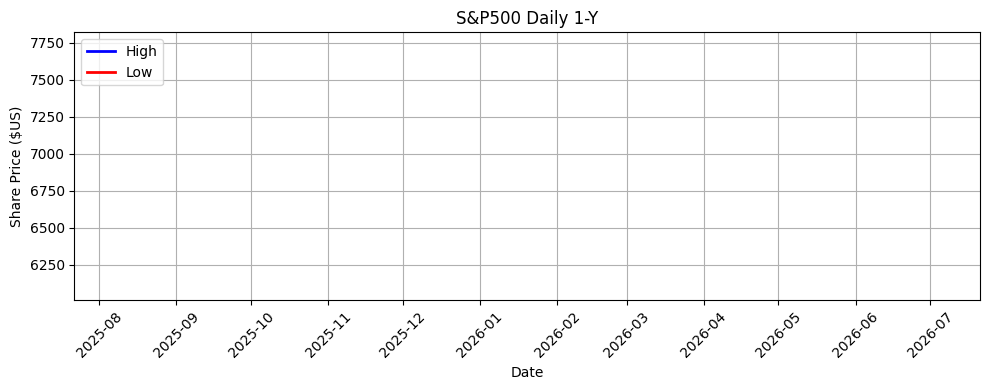

In [7]:
fig, ax = plt.subplots(figsize=(10,4))

ax.set_title('S&P500 Daily 1-Y')

ax.set_xlabel('Date')
ax.set_ylabel('Share Price ($US)')
ax.grid(True)

high_line, = ax.plot([], [], color='blue', linewidth=2, label='High')
low_line, = ax.plot([], [], color='red', linewidth=2, label='Low')

oct15 = None
nov20 = None
feb05 = None
mar20 = None

ax.legend(loc='upper left')

y_min = sp500['Low']['^GSPC'].min() - 200
y_max = sp500['High']['^GSPC'].max() + 200
ax.set_ylim(y_min, y_max)
ax.set_xlim(sp500.index.min(), sp500.index.max())
ax.tick_params(axis='x', rotation=45)

def update(frame):
    global oct15, nov20, feb05, mar20

    high_line.set_data(
        sp500.index[:frame+1],
        sp500["High"].iloc[:frame+1]
    )

    low_line.set_data(
        sp500.index[:frame+1],
        sp500["Low"].iloc[:frame+1]
    )

    artists = [high_line, low_line]

    if frame == sp500.index.get_loc('2025-10-15') and oct15 is None:
        oct15 = ax.text(
            sp500.index[sp500.index.get_loc('2025-10-15')], 7200, "Tariff Uncertainty",
            ha='center',va='center',
            fontsize=10, color='red', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='red')
        )
        artists.append(oct15)

    if frame == sp500.index.get_loc('2025-11-20') and nov20 is None:
        nov20 = ax.text(
            sp500.index[sp500.index.get_loc('2025-11-20')], 6250, "AI Bubble Fears",
            ha='center',va='center',
            fontsize=10, color='red', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='red')
        )
        artists.append(nov20)

    if frame == sp500.index.get_loc('2026-02-05') and feb05 is None:
        feb05 = ax.text(
            sp500.index[sp500.index.get_loc('2026-02-05')], 7250, "Inflation Concerns",
            ha='center',va='center',
            fontsize=10, color='red', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='red')
        )
        artists.append(feb05)

    if frame == sp500.index.get_loc('2026-03-20') and mar20 is None:
        mar20 = ax.text(
            sp500.index[sp500.index.get_loc('2026-03-20')], 6200, "Middle East Tensions",
            ha='center',va='center',
            fontsize=10, color='red', weight='bold',
            bbox=dict(facecolor='white',alpha=0.8, edgecolor='red')
        )
        artists.append(mar20)

    return tuple(artists)

ani = FuncAnimation(
    fig,
    update,
    frames=len(sp500),
    interval=100,
    blit=True
)

plt.tight_layout()
plt.show()

In [8]:
filename = f'{plot_path}/sp500_1Y.gif'
ani.save(filename, writer='pillow')

In [9]:
#HTML(ani.to_jshtml())

# Crude Oil 

In [10]:
crude.head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2025-07-21,67.199997,67.760002,66.459999,67.320000,81194
2025-07-22,66.209999,67.129997,65.989998,67.120003,269991
2025-07-23,65.250000,65.779999,64.709999,65.489998,251825
2025-07-24,66.029999,66.389999,65.330002,65.419998,281209
2025-07-25,65.160004,66.739998,65.000000,66.150002,234283


<Axes: title={'center': 'Crude Oil - 1 year'}, xlabel='Date'>

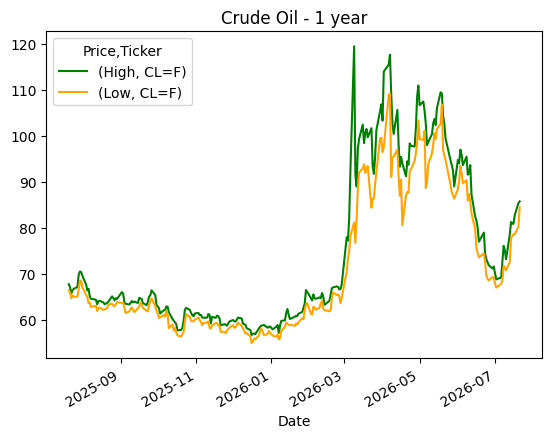

In [11]:
crude.plot(y=['High','Low'], title='Crude Oil - 1 year', color=['green','orange'])

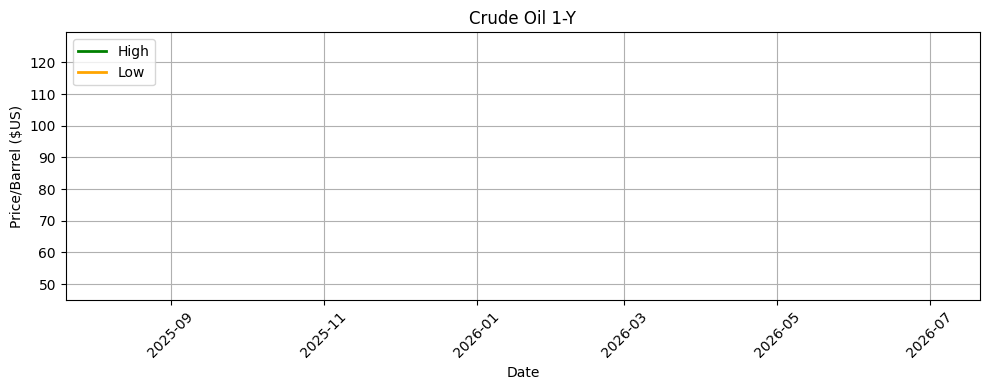

In [12]:
fig, ax = plt.subplots(figsize=(10,4))

ax.set_title('Crude Oil 1-Y')

ax.set_xlabel('Date')
ax.set_ylabel('Price/Barrel ($US)')
ax.grid(True)

high_line, = ax.plot([], [], color='green', linewidth=2, label='High')
low_line, = ax.plot([], [], color='orange', linewidth=2, label='Low')

ax.legend(loc='upper left')

y_min = crude['Low']['CL=F'].min() - 10
y_max = crude['High']['CL=F'].max() + 10
ax.set_ylim(y_min, y_max)
ax.set_xlim(crude.index.min(), crude.index.max())
ax.tick_params(axis='x', rotation=45)

def update(frame):
    high_line.set_data(
        crude.index[:frame+1],
        crude['High'].iloc[:frame+1]
    )

    low_line.set_data(
        crude.index[:frame+1],
        crude['Low'].iloc[:frame+1]
    )
    return high_line, low_line

ani = FuncAnimation(
    fig,
    update,
    frames=len(crude),
    interval=100,
    blit=True
)
plt.tight_layout()
plt.show()

In [13]:
crude_events = {
    "2026-03-03": "OPEC+ supports\nprices",
    "2026-06-13": "Israel-Iran\nconflict",
    "2026-06-23": "Ceasefire eases\noil fears"
}

In [14]:
filename = f'{plot_path}/crude_1Y.gif'
ani.save(filename, writer='pillow')

In [15]:
#HTML(ani.to_jshtml())

# Cryptocurrency - Ethereum

In [16]:
ethereum.head()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2025-07-22,3749.145508,3798.100342,3624.140381,3762.882080,45248868820
2025-07-23,3629.703613,3765.026367,3532.856445,3749.238525,41283228953
2025-07-24,3708.005615,3771.381592,3514.999268,3629.731689,40377960354
2025-07-25,3727.266846,3744.820068,3579.962891,3708.005615,42264509577
2025-07-26,3741.395996,3789.789795,3702.774170,3727.237305,24635287361


<Axes: title={'center': 'Ethereum - 1 year'}, xlabel='Date'>

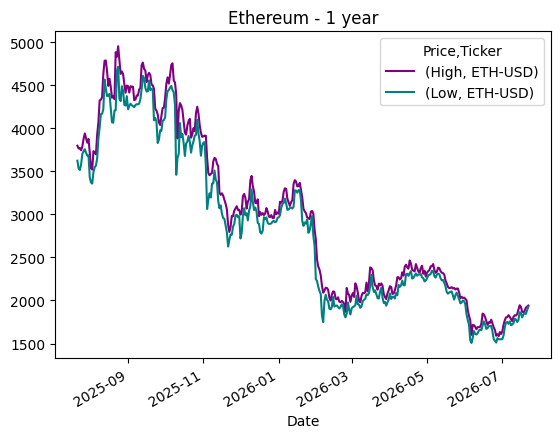

In [17]:
ethereum.plot(y=['High','Low'], title='Ethereum - 1 year', color=['purple','teal'])

In [18]:
ethereum_events = {
    "2025-11-06": "Post-election\ncrypto rally",
    "2026-01-20": "Crypto policy\noptimism",
    "2026-02-05": "Risk assets\ndecline",
    "2026-06-17": "ETF inflows\nboost ETH"
}

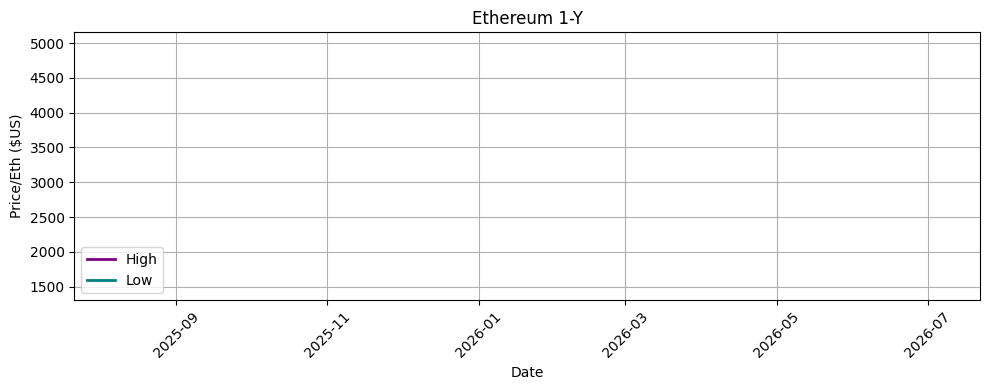

In [19]:
fig, ax = plt.subplots(figsize=(10,4))

ax.set_title('Ethereum 1-Y')

ax.set_xlabel('Date')
ax.set_ylabel('Price/Eth ($US)')
ax.grid(True)

high_line, = ax.plot([], [], color='purple', linewidth=2, label='High')
low_line, = ax.plot([], [], color='teal', linewidth=2, label='Low')

ax.legend(loc='lower left')

y_min = ethereum['Low']['ETH-USD'].min() - 200
y_max = ethereum['High']['ETH-USD'].max() + 200
ax.set_ylim(y_min, y_max)
ax.set_xlim(ethereum.index.min(), ethereum.index.max())
ax.tick_params(axis='x', rotation=45)

def update(frame):
    high_line.set_data(
        ethereum.index[:frame+1],
        ethereum['High'].iloc[:frame+1]
    )

    low_line.set_data(
        ethereum.index[:frame+1],
        ethereum['Low'].iloc[:frame+1]
    )
    return high_line, low_line

ani = FuncAnimation(
    fig,
    update,
    frames=len(ethereum),
    interval=100,
    blit=True
)
plt.tight_layout()
plt.show()

In [20]:
filename = f'{plot_path}/ethereum_1Y.gif'
ani.save(filename, writer='pillow')

In [21]:
#HTML(ani.to_jshtml())